In [1]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn
!pip install joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving multi_cloud_service_dataset.csv to multi_cloud_service_dataset.csv


In [4]:
df = pd.read_csv("multi_cloud_service_dataset.csv")
df.head()

,Service_ID,Service_Type,Cloud_Provider,Edge_Node_ID,CPU_Utilization (%),Memory_Usage (MB),Storage_Usage (GB),Network_Bandwidth (Mbps),Service_Latency (ms),Response_Time (ms),Throughput (Requests/sec),Load_Balancing (%),QoS_Score,Workload_Variability,Optimal_Service_Placement
0,S0001,Database,IBM,E3,73.724254,6966,458,684.539483,161.677301,473.292482,992.471026,83.072391,0.803979,3,0
1,S0002,AI Model,IBM,E4,25.406325,1381,981,940.781359,224.986712,319.738860,647.689492,94.095164,0.552381,1,0
2,S0003,Network,IBM,E1,25.344255,1397,185,56.317987,248.652571,223.293435,401.778413,70.469457,0.727114,3,0
3,S0004,AI Model,IBM,E4,20.908136,2513,250,326.455535,210.485614,267.325408,264.844020,64.494034,0.619383,2,0
4,S0005,AI Model,IBM,E3,91.737605,6809,299,443.794949,277.601532,107.818116,879.188722,50.725755,0.917782,1,0


In [5]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()

(1000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Service_ID                 1000 non-null   object 
 1   Service_Type               1000 non-null   object 
 2   Cloud_Provider             1000 non-null   object 
 3   Edge_Node_ID               1000 non-null   object 
 4   CPU_Utilization (%)        1000 non-null   float64
 5   Memory_Usage (MB)          1000 non-null   int64  
 6   Storage_Usage (GB)         1000 non-null   int64  
 7   Network_Bandwidth (Mbps)   1000 non-null   float64
 8   Service_Latency (ms)       1000 non-null   float64
 9   Response_Time (ms)         1000 non-null   float64
 10  Throughput (Requests/sec)  1000 non-null   float64
 11  Load_Balancing (%)         1000 non-null   float64
 12  QoS_Score                  1000 non-null   float64
 13  Workload_Variability       1000 non-nu

,0
Service_ID,0
Service_Type,0
Cloud_Provider,0
Edge_Node_ID,0
CPU_Utilization (%),0
Memory_Usage (MB),0
Storage_Usage (GB),0
Network_Bandwidth (Mbps),0
Service_Latency (ms),0
Response_Time (ms),0


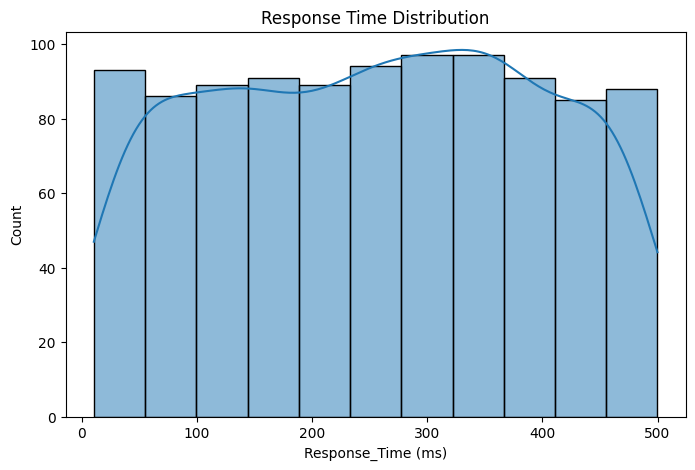

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Response_Time (ms)"], kde=True)
plt.title("Response Time Distribution")
plt.show()

In [10]:
criteria = [
    "Response Time",
    "Availability",
    "Throughput",
    "Reliability",
    "Latency",
    "Compliance",
    "Best Practices",
    "Documentation"
]

print(criteria)

['Response Time', 'Availability', 'Throughput', 'Reliability', 'Latency', 'Compliance', 'Best Practices', 'Documentation']


In [2]:
import numpy as np
import pandas as pd

criteria = [
    "Response Time",
    "Availability",
    "Throughput",
    "Reliability",
    "Latency",
    "Compliance",
    "Best Practices",
    "Documentation"
]

pairwise = np.array([
    [1,   1/5, 1/3, 1/4, 1,   1/2, 1/2, 1/2],
    [5,   1,   3,   2,   5,   3,   3,   3],
    [3,   1/3, 1,   1/2, 3,   2,   2,   2],
    [4,   1/2, 2,   1,   4,   2,   3,   2],
    [1,   1/5, 1/3, 1/4, 1,   1/2, 1/2, 1/2],
    [2,   1/3, 1/2, 1/2, 2,   1,   2,   2],
    [2,   1/3, 1/2, 1/3, 2,   1/2, 1,   2],
    [2,   1/3, 1/2, 1/2, 2,   1/2, 1/2, 1]
])

pairwise_df = pd.DataFrame(pairwise, index=criteria, columns=criteria)
pairwise_df

,Response Time,Availability,Throughput,Reliability,Latency,Compliance,Best Practices,Documentation
Response Time,1.0,0.200000,0.333333,0.250000,1.0,0.5,0.5,0.5
Availability,5.0,1.000000,3.000000,2.000000,5.0,3.0,3.0,3.0
Throughput,3.0,0.333333,1.000000,0.500000,3.0,2.0,2.0,2.0
Reliability,4.0,0.500000,2.000000,1.000000,4.0,2.0,3.0,2.0
Latency,1.0,0.200000,0.333333,0.250000,1.0,0.5,0.5,0.5
Compliance,2.0,0.333333,0.500000,0.500000,2.0,1.0,2.0,2.0
Best Practices,2.0,0.333333,0.500000,0.333333,2.0,0.5,1.0,2.0
Documentation,2.0,0.333333,0.500000,0.500000,2.0,0.5,0.5,1.0


In [3]:
column_sum = pairwise.sum(axis=0)

normalized = pairwise / column_sum

normalized_df = pd.DataFrame(normalized, index=criteria, columns=criteria)

normalized_df

,Response Time,Availability,Throughput,Reliability,Latency,Compliance,Best Practices,Documentation
Response Time,0.05,0.061856,0.040816,0.046875,0.05,0.05,0.04,0.038462
Availability,0.25,0.309278,0.367347,0.375000,0.25,0.30,0.24,0.230769
Throughput,0.15,0.103093,0.122449,0.093750,0.15,0.20,0.16,0.153846
Reliability,0.20,0.154639,0.244898,0.187500,0.20,0.20,0.24,0.153846
Latency,0.05,0.061856,0.040816,0.046875,0.05,0.05,0.04,0.038462
Compliance,0.10,0.103093,0.061224,0.093750,0.10,0.10,0.16,0.153846
Best Practices,0.10,0.103093,0.061224,0.062500,0.10,0.05,0.08,0.153846
Documentation,0.10,0.103093,0.061224,0.093750,0.10,0.05,0.04,0.076923


In [5]:
weights = normalized.mean(axis=1)

weights_df = pd.DataFrame({
    "Criteria": criteria,
    "Weight": weights
})

weights_df = weights_df.sort_values("Weight", ascending=False)

weights_df

,Criteria,Weight
1,Availability,0.290299
3,Reliability,0.197610
2,Throughput,0.141642
5,Compliance,0.108989
6,Best Practices,0.088833
7,Documentation,0.078124
0,Response Time,0.047251
4,Latency,0.047251


In [6]:
n = len(criteria)

weighted_sum = np.dot(pairwise, weights)

consistency_vector = weighted_sum / weights

lambda_max = consistency_vector.mean()

CI = (lambda_max - n) / (n - 1)

RI = 1.41

CR = CI / RI

print("Lambda Max:", round(lambda_max,3))
print("Consistency Index:", round(CI,3))
print("Consistency Ratio:", round(CR,3))

if CR < 0.10:
    print("Matrix is Consistent.")
else:
    print("Matrix is NOT Consistent.")

Lambda Max: 8.22
Consistency Index: 0.031
Consistency Ratio: 0.022
Matrix is Consistent.


In [16]:
selected_columns = [
    "Response_Time (ms)",
    "Throughput (Requests/sec)",
    "Service_Latency (ms)"
]

decision_matrix = df[selected_columns].copy()

decision_matrix.head()

,Response_Time (ms),Throughput (Requests/sec),Service_Latency (ms)
0,473.292482,992.471026,161.677301
1,319.738860,647.689492,224.986712
2,223.293435,401.778413,248.652571
3,267.325408,264.844020,210.485614
4,107.818116,879.188722,277.601532


In [18]:
selected_columns = [
    "CPU_Utilization (%)",
    "Memory_Usage (MB)",
    "Storage_Usage (GB)",
    "Network_Bandwidth (Mbps)",
    "Service_Latency (ms)",
    "Response_Time (ms)",
    "Throughput (Requests/sec)",
    "Load_Balancing (%)"
]

decision_matrix = df[selected_columns].copy()

decision_matrix.head()

,CPU_Utilization (%),Memory_Usage (MB),Storage_Usage (GB),Network_Bandwidth (Mbps),Service_Latency (ms),Response_Time (ms),Throughput (Requests/sec),Load_Balancing (%)
0,73.724254,6966,458,684.539483,161.677301,473.292482,992.471026,83.072391
1,25.406325,1381,981,940.781359,224.986712,319.738860,647.689492,94.095164
2,25.344255,1397,185,56.317987,248.652571,223.293435,401.778413,70.469457
3,20.908136,2513,250,326.455535,210.485614,267.325408,264.844020,64.494034
4,91.737605,6809,299,443.794949,277.601532,107.818116,879.188722,50.725755


In [19]:
benefit_criteria = [
    "Network_Bandwidth (Mbps)",
    "Throughput (Requests/sec)",
    "Load_Balancing (%)"
]

cost_criteria = [
    "CPU_Utilization (%)",
    "Memory_Usage (MB)",
    "Storage_Usage (GB)",
    "Service_Latency (ms)",
    "Response_Time (ms)"
]

print("Benefit Criteria:", benefit_criteria)
print("Cost Criteria:", cost_criteria)

Benefit Criteria: ['Network_Bandwidth (Mbps)', 'Throughput (Requests/sec)', 'Load_Balancing (%)']
Cost Criteria: ['CPU_Utilization (%)', 'Memory_Usage (MB)', 'Storage_Usage (GB)', 'Service_Latency (ms)', 'Response_Time (ms)']


In [20]:
norm_matrix = decision_matrix / np.sqrt((decision_matrix**2).sum())

norm_matrix.head()

,CPU_Utilization (%),Memory_Usage (MB),Storage_Usage (GB),Network_Bandwidth (Mbps),Service_Latency (ms),Response_Time (ms),Throughput (Requests/sec),Load_Balancing (%)
0,0.038015,0.045539,0.023741,0.038036,0.029916,0.051367,0.052064,0.034403
1,0.013100,0.009028,0.050852,0.052274,0.041630,0.034701,0.033977,0.038968
2,0.013068,0.009133,0.009590,0.003129,0.046009,0.024234,0.021077,0.029184
3,0.010781,0.016428,0.012959,0.018139,0.038947,0.029013,0.013893,0.026709
4,0.047303,0.044513,0.015499,0.024659,0.051365,0.011702,0.046122,0.021007


In [21]:
weights_used = weights[:len(selected_columns)]

weighted_matrix = norm_matrix * weights_used

weighted_matrix.head()

,CPU_Utilization (%),Memory_Usage (MB),Storage_Usage (GB),Network_Bandwidth (Mbps),Service_Latency (ms),Response_Time (ms),Throughput (Requests/sec),Load_Balancing (%)
0,0.001796,0.013220,0.003363,0.007516,0.001414,0.005598,0.004625,0.002688
1,0.000619,0.002621,0.007203,0.010330,0.001967,0.003782,0.003018,0.003044
2,0.000617,0.002651,0.001358,0.000618,0.002174,0.002641,0.001872,0.002280
3,0.000509,0.004769,0.001836,0.003585,0.001840,0.003162,0.001234,0.002087
4,0.002235,0.012922,0.002195,0.004873,0.002427,0.001275,0.004097,0.001641


In [23]:
benefit = [
    "Availability",
    "Throughput",
    "Reliability",
    "Compliance",
    "Best Practices",
    "Documentation"
]

cost = ["Response Time"]

ideal_best = []
ideal_worst = []

for col in selected_columns:
    if col in benefit:
        ideal_best.append(weighted_matrix[col].max())
        ideal_worst.append(weighted_matrix[col].min())
    else:
        ideal_best.append(weighted_matrix[col].min())
        ideal_worst.append(weighted_matrix[col].max())

ideal_best = np.array(ideal_best)
ideal_worst = np.array(ideal_worst)

In [24]:
distance_best = np.sqrt(((weighted_matrix - ideal_best)**2).sum(axis=1))

distance_worst = np.sqrt(((weighted_matrix - ideal_worst)**2).sum(axis=1))

In [25]:
topsis_score = distance_worst / (distance_best + distance_worst)

df["TOPSIS_Score"] = topsis_score

df["Rank"] = df["TOPSIS_Score"].rank(ascending=False)

ranking = df.sort_values("TOPSIS_Score", ascending=False)

ranking[["TOPSIS_Score","Rank"]].head(10)

,TOPSIS_Score,Rank
494,0.877300,1.0
2,0.810885,2.0
151,0.803050,3.0
355,0.801010,4.0
574,0.785912,5.0
716,0.780186,6.0
429,0.777148,7.0
855,0.775159,8.0
766,0.773870,9.0
570,0.773831,10.0


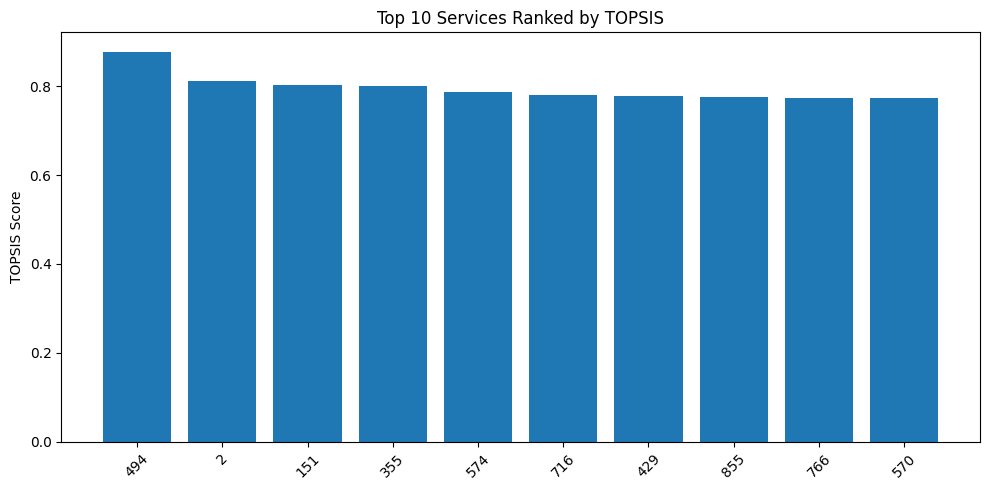

In [27]:
import matplotlib.pyplot as plt

top10 = ranking.head(10)

plt.figure(figsize=(10,5))
plt.bar(range(len(top10)), top10["TOPSIS_Score"])
plt.xticks(range(len(top10)), top10.index, rotation=45)
plt.title("Top 10 Services Ranked by TOPSIS")
plt.ylabel("TOPSIS Score")
plt.tight_layout()
plt.show()

In [28]:
criteria = [
    "CPU_Utilization (%)",
    "Memory_Usage (MB)",
    "Storage_Usage (GB)",
    "Network_Bandwidth (Mbps)",
    "Service_Latency (ms)",
    "Response_Time (ms)",
    "Throughput (Requests/sec)",
    "Load_Balancing (%)"
]

print("Number of criteria:", len(criteria))

Number of criteria: 8


In [29]:
pairwise = np.array([
    [1,   2,   2,   1/2, 1/3, 1/3, 1/4, 1/2],
    [1/2, 1,   2,   1/2, 1/3, 1/3, 1/4, 1/2],
    [1/2, 1/2, 1,   1/2, 1/3, 1/3, 1/4, 1/2],
    [2,   2,   2,   1,   2,   2,   1,   2],
    [3,   3,   3,   1/2, 1,   2,   1/2, 2],
    [3,   3,   3,   1/2, 1/2, 1,   1/2, 2],
    [4,   4,   4,   1,   2,   2,   1,   2],
    [2,   2,   2,   1/2, 1/2, 1/2, 1/2, 1]
])

pairwise_df = pd.DataFrame(
    pairwise,
    index=criteria,
    columns=criteria
)

pairwise_df

,CPU_Utilization (%),Memory_Usage (MB),Storage_Usage (GB),Network_Bandwidth (Mbps),Service_Latency (ms),Response_Time (ms),Throughput (Requests/sec),Load_Balancing (%)
CPU_Utilization (%),1.0,2.0,2.0,0.5,0.333333,0.333333,0.25,0.5
Memory_Usage (MB),0.5,1.0,2.0,0.5,0.333333,0.333333,0.25,0.5
Storage_Usage (GB),0.5,0.5,1.0,0.5,0.333333,0.333333,0.25,0.5
Network_Bandwidth (Mbps),2.0,2.0,2.0,1.0,2.000000,2.000000,1.00,2.0
Service_Latency (ms),3.0,3.0,3.0,0.5,1.000000,2.000000,0.50,2.0
Response_Time (ms),3.0,3.0,3.0,0.5,0.500000,1.000000,0.50,2.0
Throughput (Requests/sec),4.0,4.0,4.0,1.0,2.000000,2.000000,1.00,2.0
Load_Balancing (%),2.0,2.0,2.0,0.5,0.500000,0.500000,0.50,1.0


In [30]:
column_sum = pairwise.sum(axis=0)

normalized_matrix = pairwise / column_sum

weights = normalized_matrix.mean(axis=1)

weights_df = pd.DataFrame({
    "Criteria": criteria,
    "Weight": weights
})

weights_df = weights_df.sort_values(
    "Weight",
    ascending=False
)

weights_df

,Criteria,Weight
6,Throughput (Requests/sec),0.229485
3,Network_Bandwidth (Mbps),0.186416
4,Service_Latency (ms),0.162887
5,Response_Time (ms),0.139253
7,Load_Balancing (%),0.098461
0,CPU_Utilization (%),0.071916
1,Memory_Usage (MB),0.060867
2,Storage_Usage (GB),0.050716


In [31]:
n = len(criteria)

weighted_sum = np.dot(pairwise, weights)

consistency_vector = weighted_sum / weights

lambda_max = consistency_vector.mean()

CI = (lambda_max - n) / (n - 1)

RI = 1.41

CR = CI / RI

print("Lambda Max:", round(lambda_max, 4))
print("Consistency Index:", round(CI, 4))
print("Consistency Ratio:", round(CR, 4))

if CR < 0.10:
    print("AHP Matrix is Consistent")
else:
    print("AHP Matrix is Not Consistent")

Lambda Max: 8.3882
Consistency Index: 0.0555
Consistency Ratio: 0.0393
AHP Matrix is Consistent


In [32]:
weights_dict = dict(zip(criteria, weights))

weights_used = np.array([
    weights_dict["CPU_Utilization (%)"],
    weights_dict["Memory_Usage (MB)"],
    weights_dict["Storage_Usage (GB)"],
    weights_dict["Network_Bandwidth (Mbps)"],
    weights_dict["Service_Latency (ms)"],
    weights_dict["Response_Time (ms)"],
    weights_dict["Throughput (Requests/sec)"],
    weights_dict["Load_Balancing (%)"]
])

print("AHP Weights:")
for c, w in zip(criteria, weights_used):
    print(c, ":", round(w, 4))

print("\nSum:", round(weights_used.sum(), 4))

AHP Weights:
CPU_Utilization (%) : 0.0719
Memory_Usage (MB) : 0.0609
Storage_Usage (GB) : 0.0507
Network_Bandwidth (Mbps) : 0.1864
Service_Latency (ms) : 0.1629
Response_Time (ms) : 0.1393
Throughput (Requests/sec) : 0.2295
Load_Balancing (%) : 0.0985

Sum: 1.0


In [33]:
norm_matrix = decision_matrix / np.sqrt(
    (decision_matrix ** 2).sum(axis=0)
)

norm_matrix.head()

,CPU_Utilization (%),Memory_Usage (MB),Storage_Usage (GB),Network_Bandwidth (Mbps),Service_Latency (ms),Response_Time (ms),Throughput (Requests/sec),Load_Balancing (%)
0,0.038015,0.045539,0.023741,0.038036,0.029916,0.051367,0.052064,0.034403
1,0.013100,0.009028,0.050852,0.052274,0.041630,0.034701,0.033977,0.038968
2,0.013068,0.009133,0.009590,0.003129,0.046009,0.024234,0.021077,0.029184
3,0.010781,0.016428,0.012959,0.018139,0.038947,0.029013,0.013893,0.026709
4,0.047303,0.044513,0.015499,0.024659,0.051365,0.011702,0.046122,0.021007


In [34]:
weighted_matrix = norm_matrix * weights_used

weighted_matrix.head()

,CPU_Utilization (%),Memory_Usage (MB),Storage_Usage (GB),Network_Bandwidth (Mbps),Service_Latency (ms),Response_Time (ms),Throughput (Requests/sec),Load_Balancing (%)
0,0.002734,0.002772,0.001204,0.007091,0.004873,0.007153,0.011948,0.003387
1,0.000942,0.000550,0.002579,0.009745,0.006781,0.004832,0.007797,0.003837
2,0.000940,0.000556,0.000486,0.000583,0.007494,0.003375,0.004837,0.002873
3,0.000775,0.001000,0.000657,0.003381,0.006344,0.004040,0.003188,0.002630
4,0.003402,0.002709,0.000786,0.004597,0.008367,0.001629,0.010584,0.002068


In [35]:
benefit_criteria = [
    "Network_Bandwidth (Mbps)",
    "Throughput (Requests/sec)",
    "Load_Balancing (%)"
]

cost_criteria = [
    "CPU_Utilization (%)",
    "Memory_Usage (MB)",
    "Storage_Usage (GB)",
    "Service_Latency (ms)",
    "Response_Time (ms)"
]

In [36]:
ideal_best = []
ideal_worst = []

for col in selected_columns:
    if col in benefit_criteria:
        ideal_best.append(weighted_matrix[col].max())
        ideal_worst.append(weighted_matrix[col].min())
    else:
        ideal_best.append(weighted_matrix[col].min())
        ideal_worst.append(weighted_matrix[col].max())

ideal_best = np.array(ideal_best)
ideal_worst = np.array(ideal_worst)

print("Ideal Best:")
print(ideal_best)

print("\nIdeal Worst:")
print(ideal_worst)

Ideal Best:
[0.00074202 0.00020452 0.00013145 0.01033378 0.00016916 0.00015578
 0.01201837 0.00407707]

Ideal Worst:
[0.00351823 0.00325805 0.00262633 0.00010549 0.00903339 0.00755546
 0.00063523 0.00204156]


In [37]:
distance_best = np.sqrt(
    ((weighted_matrix - ideal_best) ** 2).sum(axis=1)
)

distance_worst = np.sqrt(
    ((weighted_matrix - ideal_worst) ** 2).sum(axis=1)
)

In [38]:
topsis_score = distance_worst / (
    distance_best + distance_worst
)

df["TOPSIS_Score"] = topsis_score

df[["Service_ID", "TOPSIS_Score"]].head()

,Service_ID,TOPSIS_Score
0,S0001,0.592889
1,S0002,0.581653
2,S0003,0.341158
3,S0004,0.351636
4,S0005,0.532449


In [39]:
df["TOPSIS_Rank"] = (
    df["TOPSIS_Score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

ranking = df.sort_values(
    "TOPSIS_Score",
    ascending=False
)

ranking[
    [
        "Service_ID",
        "Service_Type",
        "Cloud_Provider",
        "TOPSIS_Score",
        "TOPSIS_Rank"
    ]
].head(10)

,Service_ID,Service_Type,Cloud_Provider,TOPSIS_Score,TOPSIS_Rank
280,S0281,Storage,Google Cloud,0.882874,1
874,S0875,Compute,IBM,0.865703,2
289,S0290,Database,Azure,0.837556,3
106,S0107,Network,AWS,0.831649,4
438,S0439,Database,Google Cloud,0.815629,5
318,S0319,Storage,IBM,0.812017,6
628,S0629,Database,IBM,0.806790,7
690,S0691,AI Model,IBM,0.806111,8
719,S0720,Storage,IBM,0.803430,9
425,S0426,Storage,Azure,0.802283,10


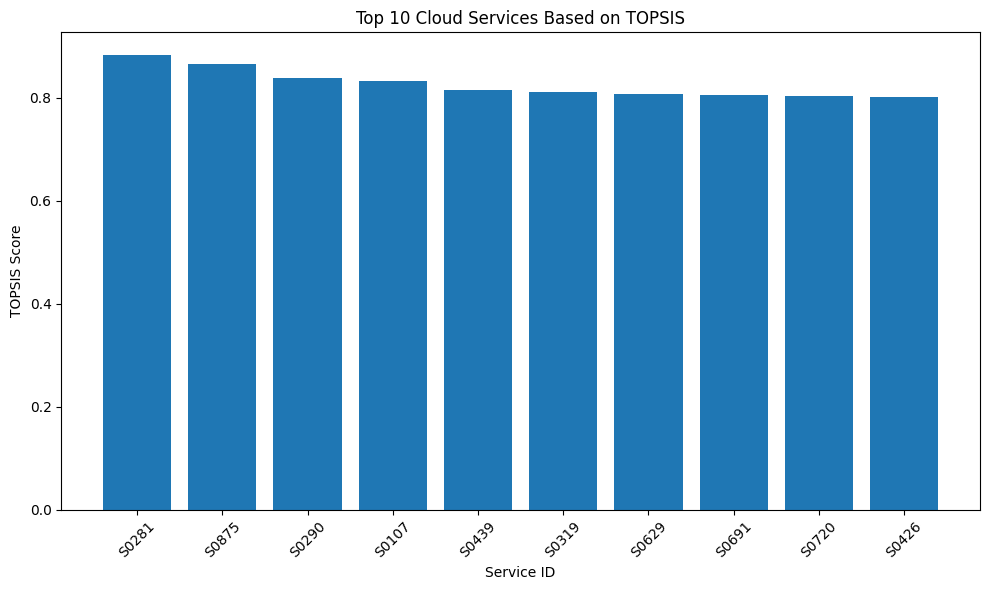

In [40]:
top10 = ranking.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top10["Service_ID"],
    top10["TOPSIS_Score"]
)

plt.title("Top 10 Cloud Services Based on TOPSIS")
plt.xlabel("Service ID")
plt.ylabel("TOPSIS Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [41]:
features = [
    "CPU_Utilization (%)",
    "Memory_Usage (MB)",
    "Storage_Usage (GB)",
    "Network_Bandwidth (Mbps)",
    "Service_Latency (ms)",
    "Response_Time (ms)",
    "Throughput (Requests/sec)",
    "Load_Balancing (%)"
]

X = df[features]
y = df["TOPSIS_Score"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1000, 8)
Target shape: (1000,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 8)
Testing data: (200, 8)


In [43]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [44]:
y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0.57437835 0.48237447 0.32976515 0.61478359 0.37197391 0.37051376
 0.42708003 0.34797367 0.5391942  0.46490666]


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²   :", round(r2, 4))

MAE : 0.0185
RMSE: 0.0233
R²   : 0.9649


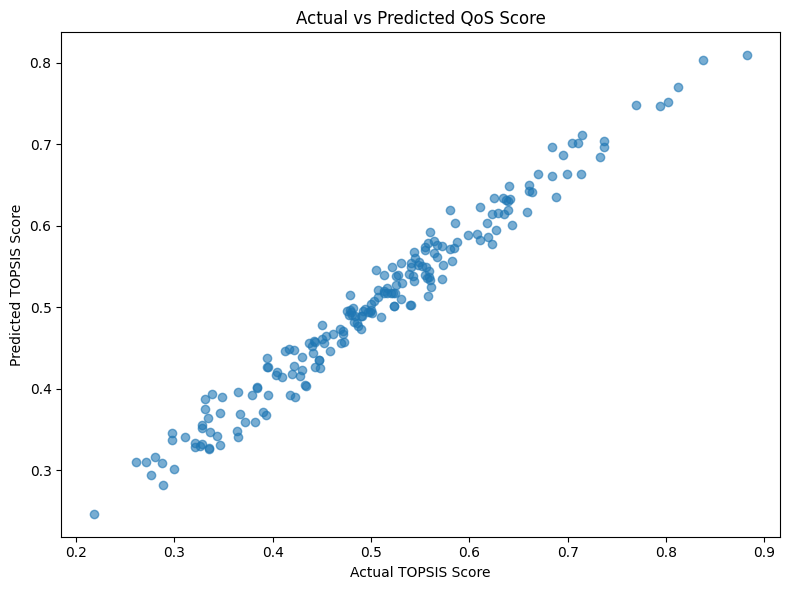

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual TOPSIS Score")
plt.ylabel("Predicted TOPSIS Score")
plt.title("Actual vs Predicted QoS Score")

plt.tight_layout()
plt.show()

In [47]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(
    ascending=False
)

importance

,0
Throughput (Requests/sec),0.454909
Network_Bandwidth (Mbps),0.289913
Service_Latency (ms),0.165025
Response_Time (ms),0.066096
CPU_Utilization (%),0.006731
Memory_Usage (MB),0.006120
Storage_Usage (GB),0.006085
Load_Balancing (%),0.005121


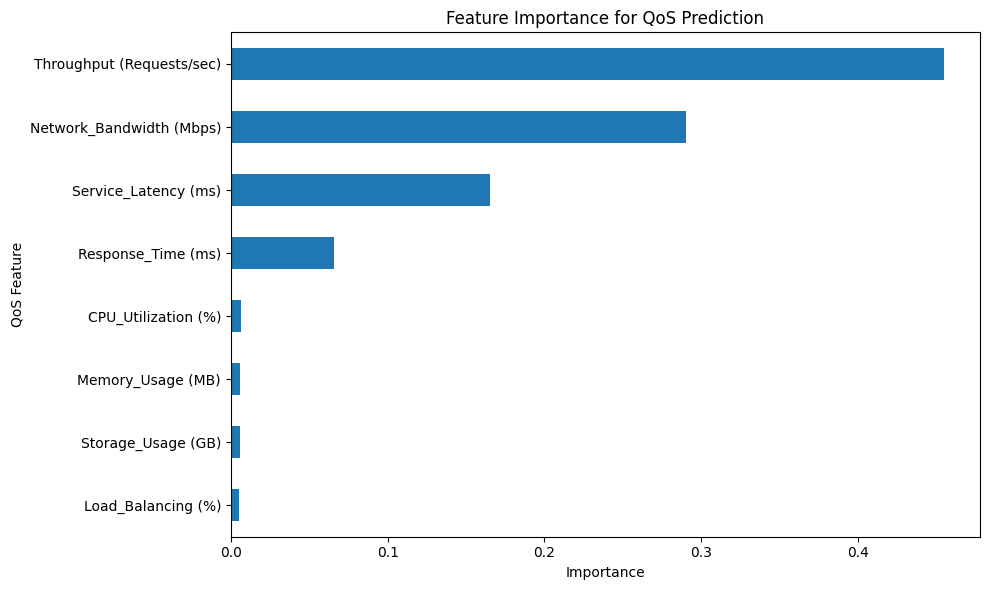

In [48]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(
    kind="barh"
)

plt.title("Feature Importance for QoS Prediction")
plt.xlabel("Importance")
plt.ylabel("QoS Feature")

plt.tight_layout()
plt.show()

In [49]:
import joblib

joblib.dump(
    model,
    "cloud_qos_random_forest.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [50]:
from google.colab import files

files.download(
    "cloud_qos_random_forest.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
def recommend_service(
    cpu,
    memory,
    storage,
    bandwidth,
    latency,
    response_time,
    throughput,
    load_balancing
):
    input_data = pd.DataFrame([[
        cpu,
        memory,
        storage,
        bandwidth,
        latency,
        response_time,
        throughput,
        load_balancing
    ]], columns=features)

    predicted_score = model.predict(input_data)[0]

    return round(float(predicted_score), 4)

In [52]:
predicted_score = recommend_service(
    cpu=30,
    memory=2000,
    storage=300,
    bandwidth=800,
    latency=50,
    response_time=100,
    throughput=800,
    load_balancing=90
)

print("Predicted QoS Score:", predicted_score)

Predicted QoS Score: 0.7546


In [53]:
top_services = ranking[
    [
        "Service_ID",
        "Service_Type",
        "Cloud_Provider",
        "Service_Latency (ms)",
        "Response_Time (ms)",
        "Throughput (Requests/sec)",
        "TOPSIS_Score",
        "TOPSIS_Rank"
    ]
].head(10)

top_services

,Service_ID,Service_Type,Cloud_Provider,Service_Latency (ms),Response_Time (ms),Throughput (Requests/sec),TOPSIS_Score,TOPSIS_Rank
280,S0281,Storage,Google Cloud,8.112581,64.885739,984.912940,0.882874,1
874,S0875,Compute,IBM,41.761444,15.396546,961.614495,0.865703,2
289,S0290,Database,Azure,61.626855,23.460576,896.640758,0.837556,3
106,S0107,Network,AWS,12.925958,28.185527,877.137895,0.831649,4
438,S0439,Database,Google Cloud,60.694238,153.959291,901.003229,0.815629,5
318,S0319,Storage,IBM,94.033764,14.905101,963.793827,0.812017,6
628,S0629,Database,IBM,20.509447,141.567409,883.827313,0.806790,7
690,S0691,AI Model,IBM,69.859277,127.933979,944.725675,0.806111,8
719,S0720,Storage,IBM,80.252563,39.404014,935.909282,0.803430,9
425,S0426,Storage,Azure,20.482104,40.597695,886.953881,0.802283,10


In [54]:
best_service = ranking.iloc[0]

print("Recommended Service")
print("-------------------")
print("Service ID:", best_service["Service_ID"])
print("Service Type:", best_service["Service_Type"])
print("Cloud Provider:", best_service["Cloud_Provider"])
print("TOPSIS Score:", round(best_service["TOPSIS_Score"], 4))
print("Rank:", int(best_service["TOPSIS_Rank"]))

Recommended Service
-------------------
Service ID: S0281
Service Type: Storage
Cloud Provider: Google Cloud
TOPSIS Score: 0.8829
Rank: 1


In [55]:
provider_comparison = (
    df.groupby("Cloud_Provider")["TOPSIS_Score"]
    .mean()
    .sort_values(ascending=False)
)

provider_comparison

,TOPSIS_Score
Cloud_Provider,
IBM,0.509234
Azure,0.507757
AWS,0.497785
Google Cloud,0.496091


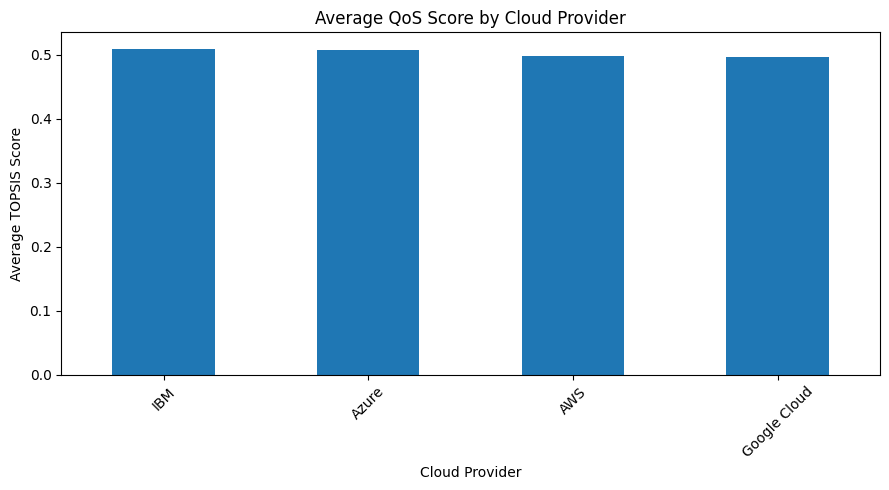

In [56]:
plt.figure(figsize=(9, 5))

provider_comparison.plot(
    kind="bar"
)

plt.title("Average QoS Score by Cloud Provider")
plt.xlabel("Cloud Provider")
plt.ylabel("Average TOPSIS Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [57]:
service_type_comparison = (
    df.groupby("Service_Type")["TOPSIS_Score"]
    .mean()
    .sort_values(ascending=False)
)

service_type_comparison

,TOPSIS_Score
Service_Type,
Database,0.506554
Network,0.505037
AI Model,0.502309
Storage,0.499678
Compute,0.499279


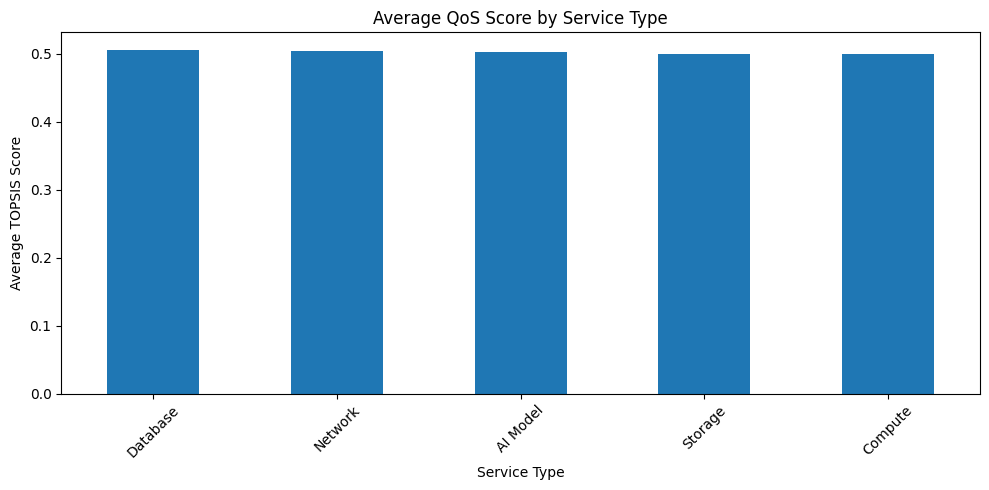

In [58]:
plt.figure(figsize=(10, 5))

service_type_comparison.plot(
    kind="bar"
)

plt.title("Average QoS Score by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average TOPSIS Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

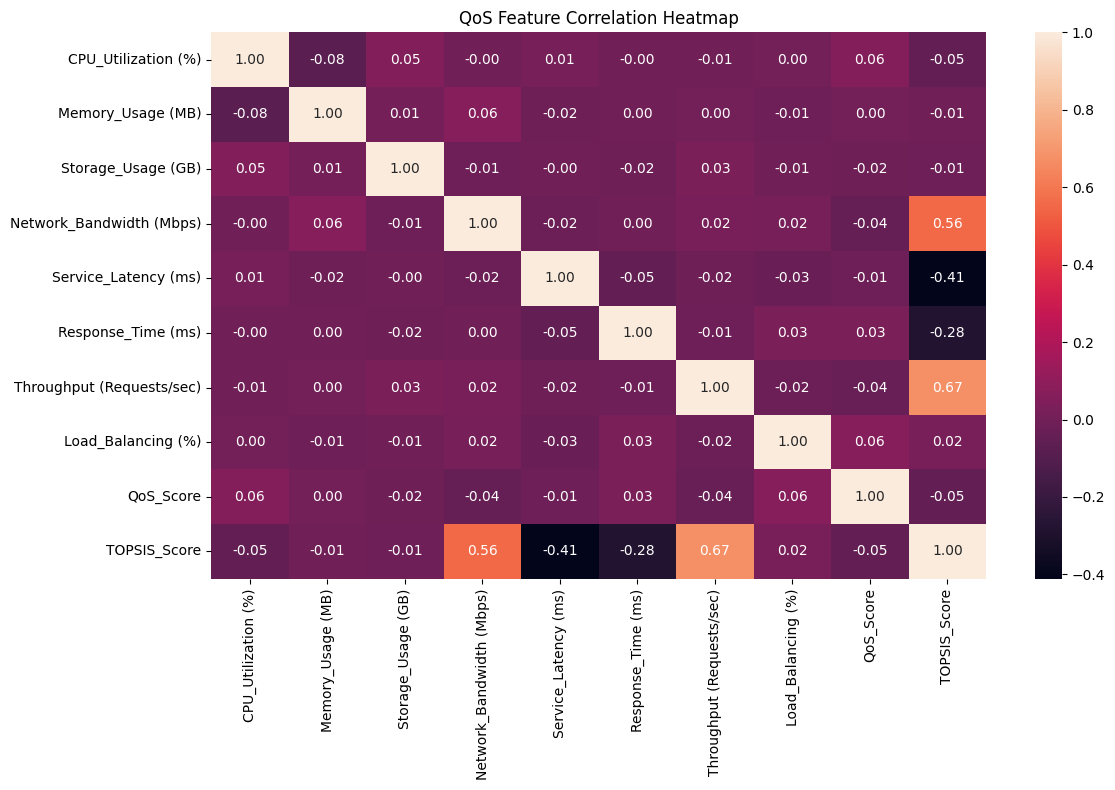

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

correlation_data = df[features + ["QoS_Score", "TOPSIS_Score"]]

sns.heatmap(
    correlation_data.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("QoS Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [61]:
print("========== PROJECT RESULTS ==========")

print("\nDataset Shape:")
print(df.shape)

print("\nAHP Weights:")
print(weights_df)

print("\nTop 5 Recommended Services:")
print(
    ranking[
        [
            "Service_ID",
            "Service_Type",
            "Cloud_Provider",
            "TOPSIS_Score",
            "TOPSIS_Rank"
        ]
    ].head(5)
)

print("\nRandom Forest Performance:")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

print("\nBest Service:")
print(best_service["Service_ID"])
print("Provider:", best_service["Cloud_Provider"])
print("TOPSIS Score:", round(best_service["TOPSIS_Score"], 4))

========== PROJECT RESULTS ==========

Dataset Shape:
(1000, 18)

AHP Weights:
                    Criteria    Weight
6  Throughput (Requests/sec)  0.229485
3   Network_Bandwidth (Mbps)  0.186416
4       Service_Latency (ms)  0.162887
5         Response_Time (ms)  0.139253
7         Load_Balancing (%)  0.098461
0        CPU_Utilization (%)  0.071916
1          Memory_Usage (MB)  0.060867
2         Storage_Usage (GB)  0.050716

Top 5 Recommended Services:
    Service_ID Service_Type Cloud_Provider  TOPSIS_Score  TOPSIS_Rank
280      S0281      Storage   Google Cloud      0.882874            1
874      S0875      Compute            IBM      0.865703            2
289      S0290     Database          Azure      0.837556            3
106      S0107      Network            AWS      0.831649            4
438      S0439     Database   Google Cloud      0.815629            5

Random Forest Performance:
MAE : 0.0185
RMSE: 0.0233
R²  : 0.9649

Best Service:
S0281
Provider: Google Cloud
TOPSIS Sco

In [62]:
ranking.to_csv(
    "cloud_service_ranking.csv",
    index=False
)

print("Ranking saved successfully.")

Ranking saved successfully.


In [63]:
from google.colab import files

files.download("cloud_service_ranking.csv")
files.download("cloud_qos_random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>